# <img src="https://epfl-ada.github.io/assets/img/ada.svg" width="40" /> The Social Fabric They Weave

This notebook contains our analysis and its results on the Reddit dataset.

Our primary goal was to find and demonstrate measurable links between major world events (like a football match or an election) and immediate behavioral shifts inside subreddits. We focused our analysis on a few questions grouped into three main parts.

1. **Political events** (e.g. 2016 U.S. presidential election)

- How do major political events affect interaction patterns and topic trends on Reddit?

2. **Sports events** (e.g. English Premier League, the Super Bowl)

- How do major sports events and e-sports tournaments reflect in Reddit activity and community interactions?

3. **Holidays** (e.g. Christmas, New Year's Day, or Mother's Day)

- How do holidays affect subreddits activity?

In [1]:
import pandas as pd

### The datasets

We used both the title and body datasets, respectively `df_title` and `df_body`. To get additional and interesting statistics, we also used additional datasets described below. For each dataset, we removed any data that didn't match the timestamps we needed.


- The subreddits embedding dataset `df_subreddits` represents each subreddit as a 300-dimensional vector, which we can use to compute similarities and therefore cluster subreddits to analyze different groups, like sports or politics related communities.
- The English Premier League dataset `df_english_pl` consists of a list of all English Premier League matches.
- The E-Sports tournaments dataset `df_esports` consists of a list of all esports tournaments.
- The Superbowl dataset `df_superbowl` consists of a list of all Superbowl games.
- The holiday dataset `df_holidays` consists of a list of all holidays in the world.

For the political part of our analysis, we primarily focused on the 2016 U.S. Presidential election and Brexit, and therefore did not need any dataset.


In [1]:
from src.data import load_data
df_body, df_title, df_subreddits, df_english_pl, df_esports, df_superbowl, df_holidays = load_data()

100%|██████████| 173M/173M [00:10<00:00, 17.4MB/s] 

Extracting files...


### Sports
This part focuses on the different sports datasets. Let's start with e-sports by plotting the number of mentions over time. Of course, the number is very low, but with clustering we will be able to regroup with other subreddits and have a lot more data on interactions.

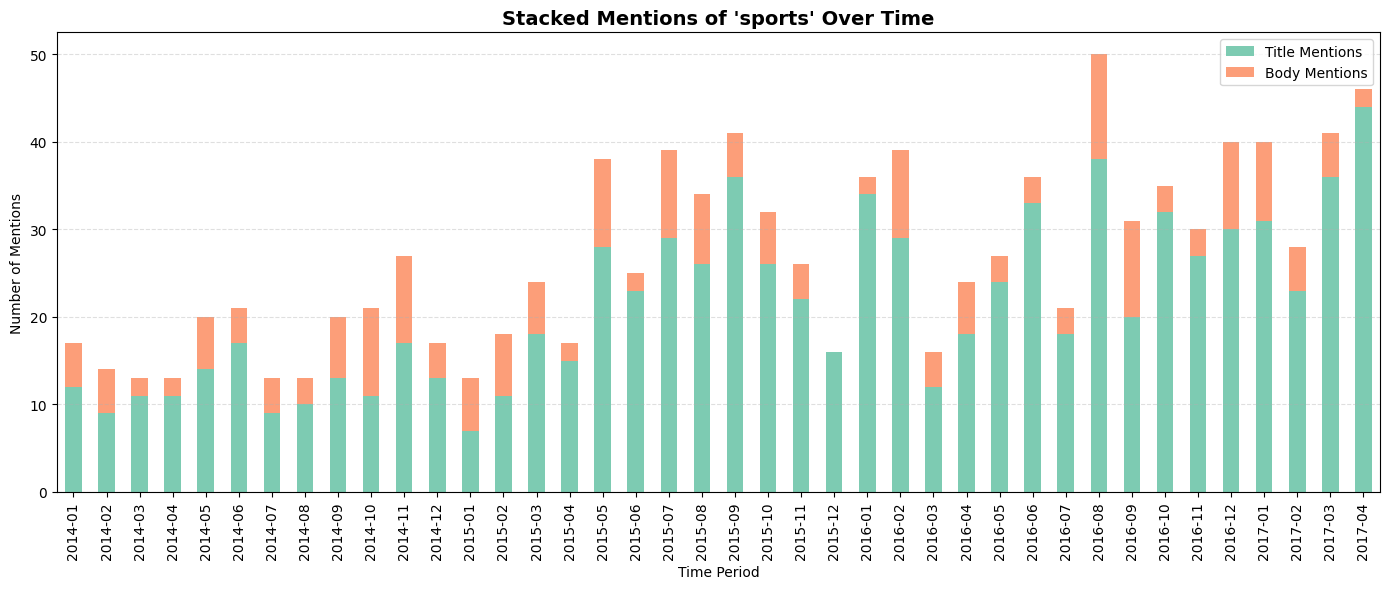

In [3]:
from src.utils import count_pattern_by_period
from src.visualization import plot_mentions_over_time
PATTERN = "sports"
counts_df = count_pattern_by_period(df_body, df_title, pattern=PATTERN)
plot_mentions_over_time(counts_df, pattern=PATTERN, period="M")

### Holidays
This part focuses on the holiday dataset `df_holidays`. It is a demonstration of our interest and of the potential the dataset gives us. We first show the most popular holidays.

In [4]:
df_holidays.Name.value_counts()[:5]

Name
Christmas Day       558
Good Friday         547
Easter Monday       467
New Year's Day      426
Independence Day    368
Name: count, dtype: int64

This dataset allows us to isolate the country of the holiday, which might prove useful to identify the origin of the subreddits.

In [5]:
print(df_holidays[df_holidays['Type'] == 'Public holiday']["ADM_name"])

44           Aruba
45           Aruba
46           Aruba
47           Aruba
48           Aruba
           ...    
44379    Palestine
44386    Palestine
44387    Palestine
44388    Palestine
44389    Palestine
Name: ADM_name, Length: 10418, dtype: object


### Methods
We wish to implement different methods to analyze the data. Here is some proof of concept.

The first method consists of finding clusters that match our 3 event categories (sports, political and holidays). We can't just pick the most active subreddits and analyze them since they have nothing to do with our categories.

Here's what we implement in order:
- Cluster the filtered subreddit data (this prevents us to look through thousands of subreddits one by one).
- Manually pick good subreddit names that match each category.
- Find nearest neighbors of the 3 created subreddit lists.

By the end of this section we'll be ready to start the exploratory analysis.

In [4]:
from src.preprocessing import filter_active_subreddits
active_subreddits, total_counts = filter_active_subreddits(df_body, df_title, df_subreddits)
total = (total_counts['POST_COUNT_TOTAL'] < 20).sum()
print('Subreddits with less than 20 interactions:', total, 'out of', len(total_counts), '. Majority, so we will keep them for the moment.')

Subreddits with less than 20 interactions: 43868 out of 51278 . Majority, so we will keep them for the moment.


To cluster our subreddits, we use two approaches:
1. K-Means clustering (on the whole dataset)
2. Nearest neighbors (on the lists created on the previous step)

##### K-Means Clustering
Here we are apllying K-means to cluster subreddits based on their similarities, thanks to the embeddings dataset:
- Dimensionality Reduction (PCA):


In [8]:
from src.clustering import reduce_dimensions_pca

embeddings_pca, pca_model = reduce_dimensions_pca(active_subreddits.drop(columns=['SUBREDDIT']), n_components=50)
print(f"Explained variance: {pca_model.explained_variance_ratio_.sum():.2%}")

PCA explained variance ratio: 0.94
Explained variance: 94.22%


In [9]:
from src.clustering import evaluate_clustering_range

metrics_df = evaluate_clustering_range(embeddings_pca)
metrics_df[['n_clusters', 'silhouette_score', 'davies_bouldin_score']]

,n_clusters,silhouette_score,davies_bouldin_score
0,5,0.107934,2.482055
1,10,0.096830,2.157209
2,15,0.107599,2.226119
3,20,0.112064,2.132075
4,25,0.111070,2.138788
5,30,0.117537,2.112959
6,35,0.112374,2.160271
7,40,0.119110,2.146537
8,45,0.109498,2.106760
9,50,0.116629,2.079414


In [10]:
from src.clustering import perform_kmeans_clustering

cluster_labels, kmeans_model = perform_kmeans_clustering(embeddings_pca)

In [11]:
from src.clustering import reduce_to_2d_tsne
embeddings_2d = reduce_to_2d_tsne(embeddings_pca)

Reducing 50D embeddings to 2D using t-SNE...
This may take a few minutes...


In [12]:
from src.clustering import create_cluster_visualization_df
viz_df = create_cluster_visualization_df(
    embeddings_2d,
    active_subreddits['SUBREDDIT'],
    cluster_labels
)

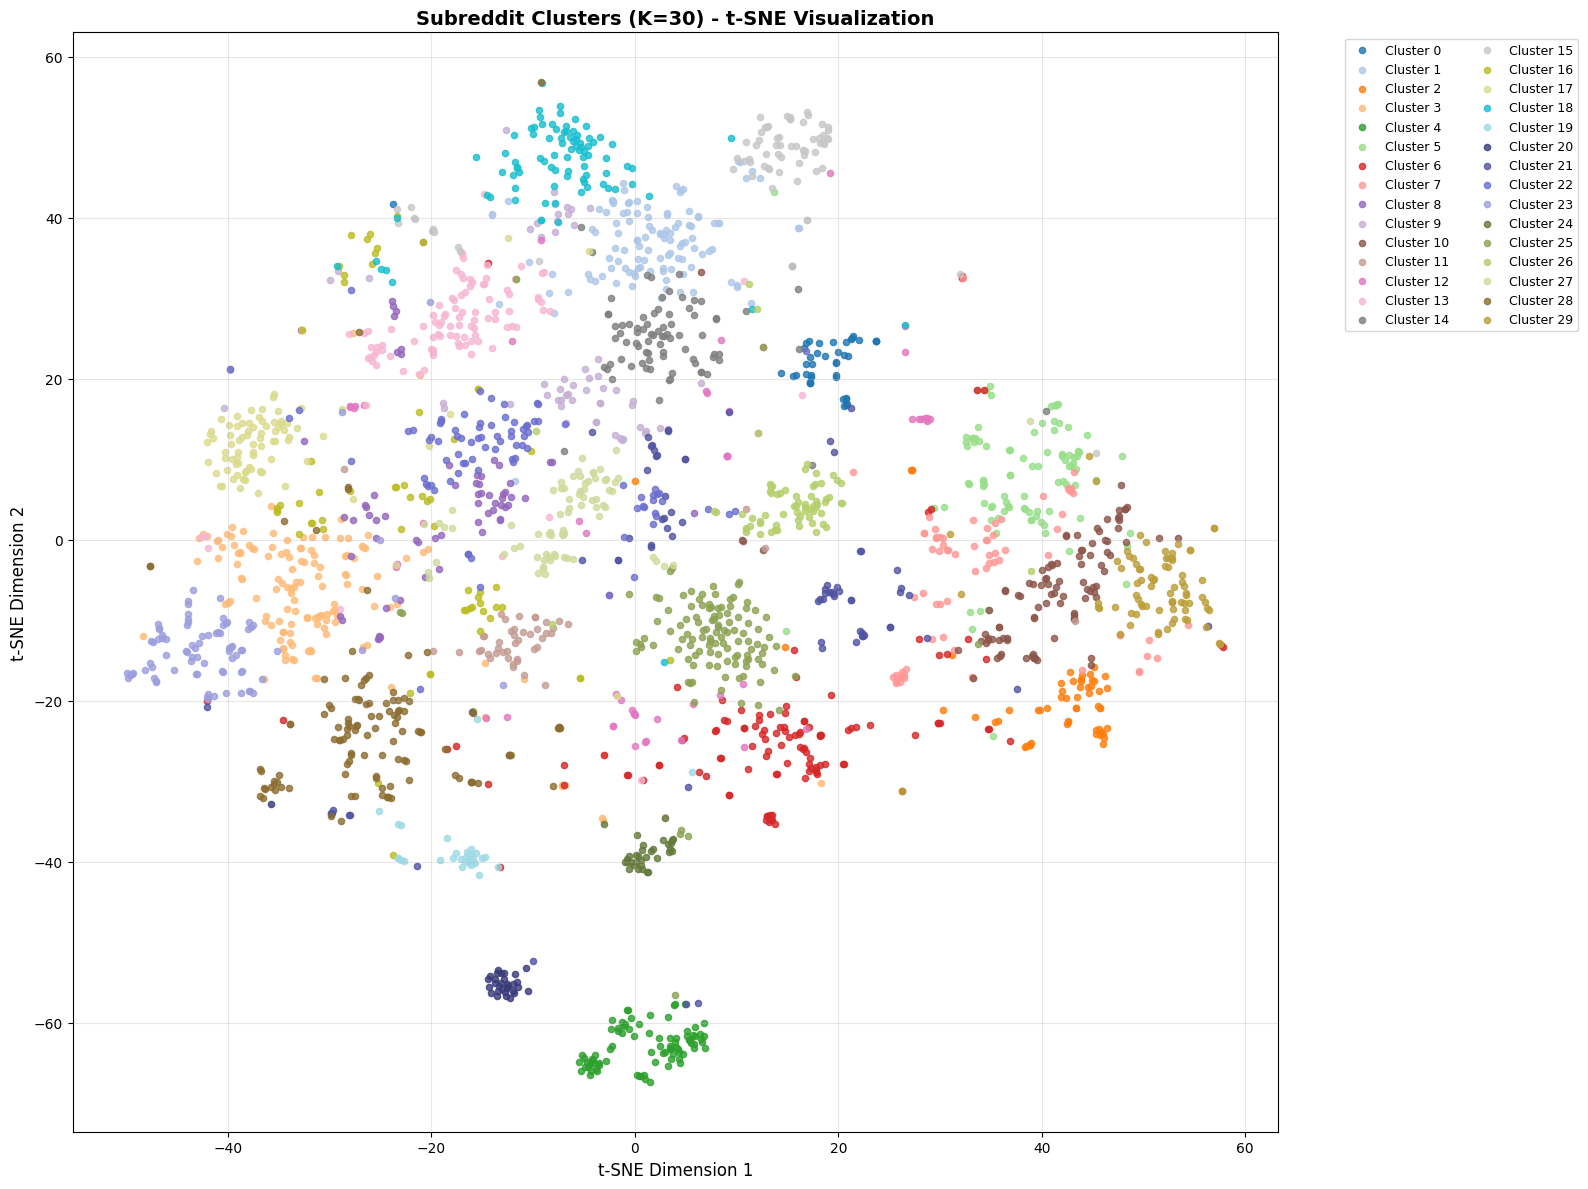

In [13]:
from src.visualization import plot_cluster_overview
plot_cluster_overview(
    viz_df
    #save_path='subreddit_clusters_tsne.png' TO ADD  !!!
);

## Top active subreddits per cluster

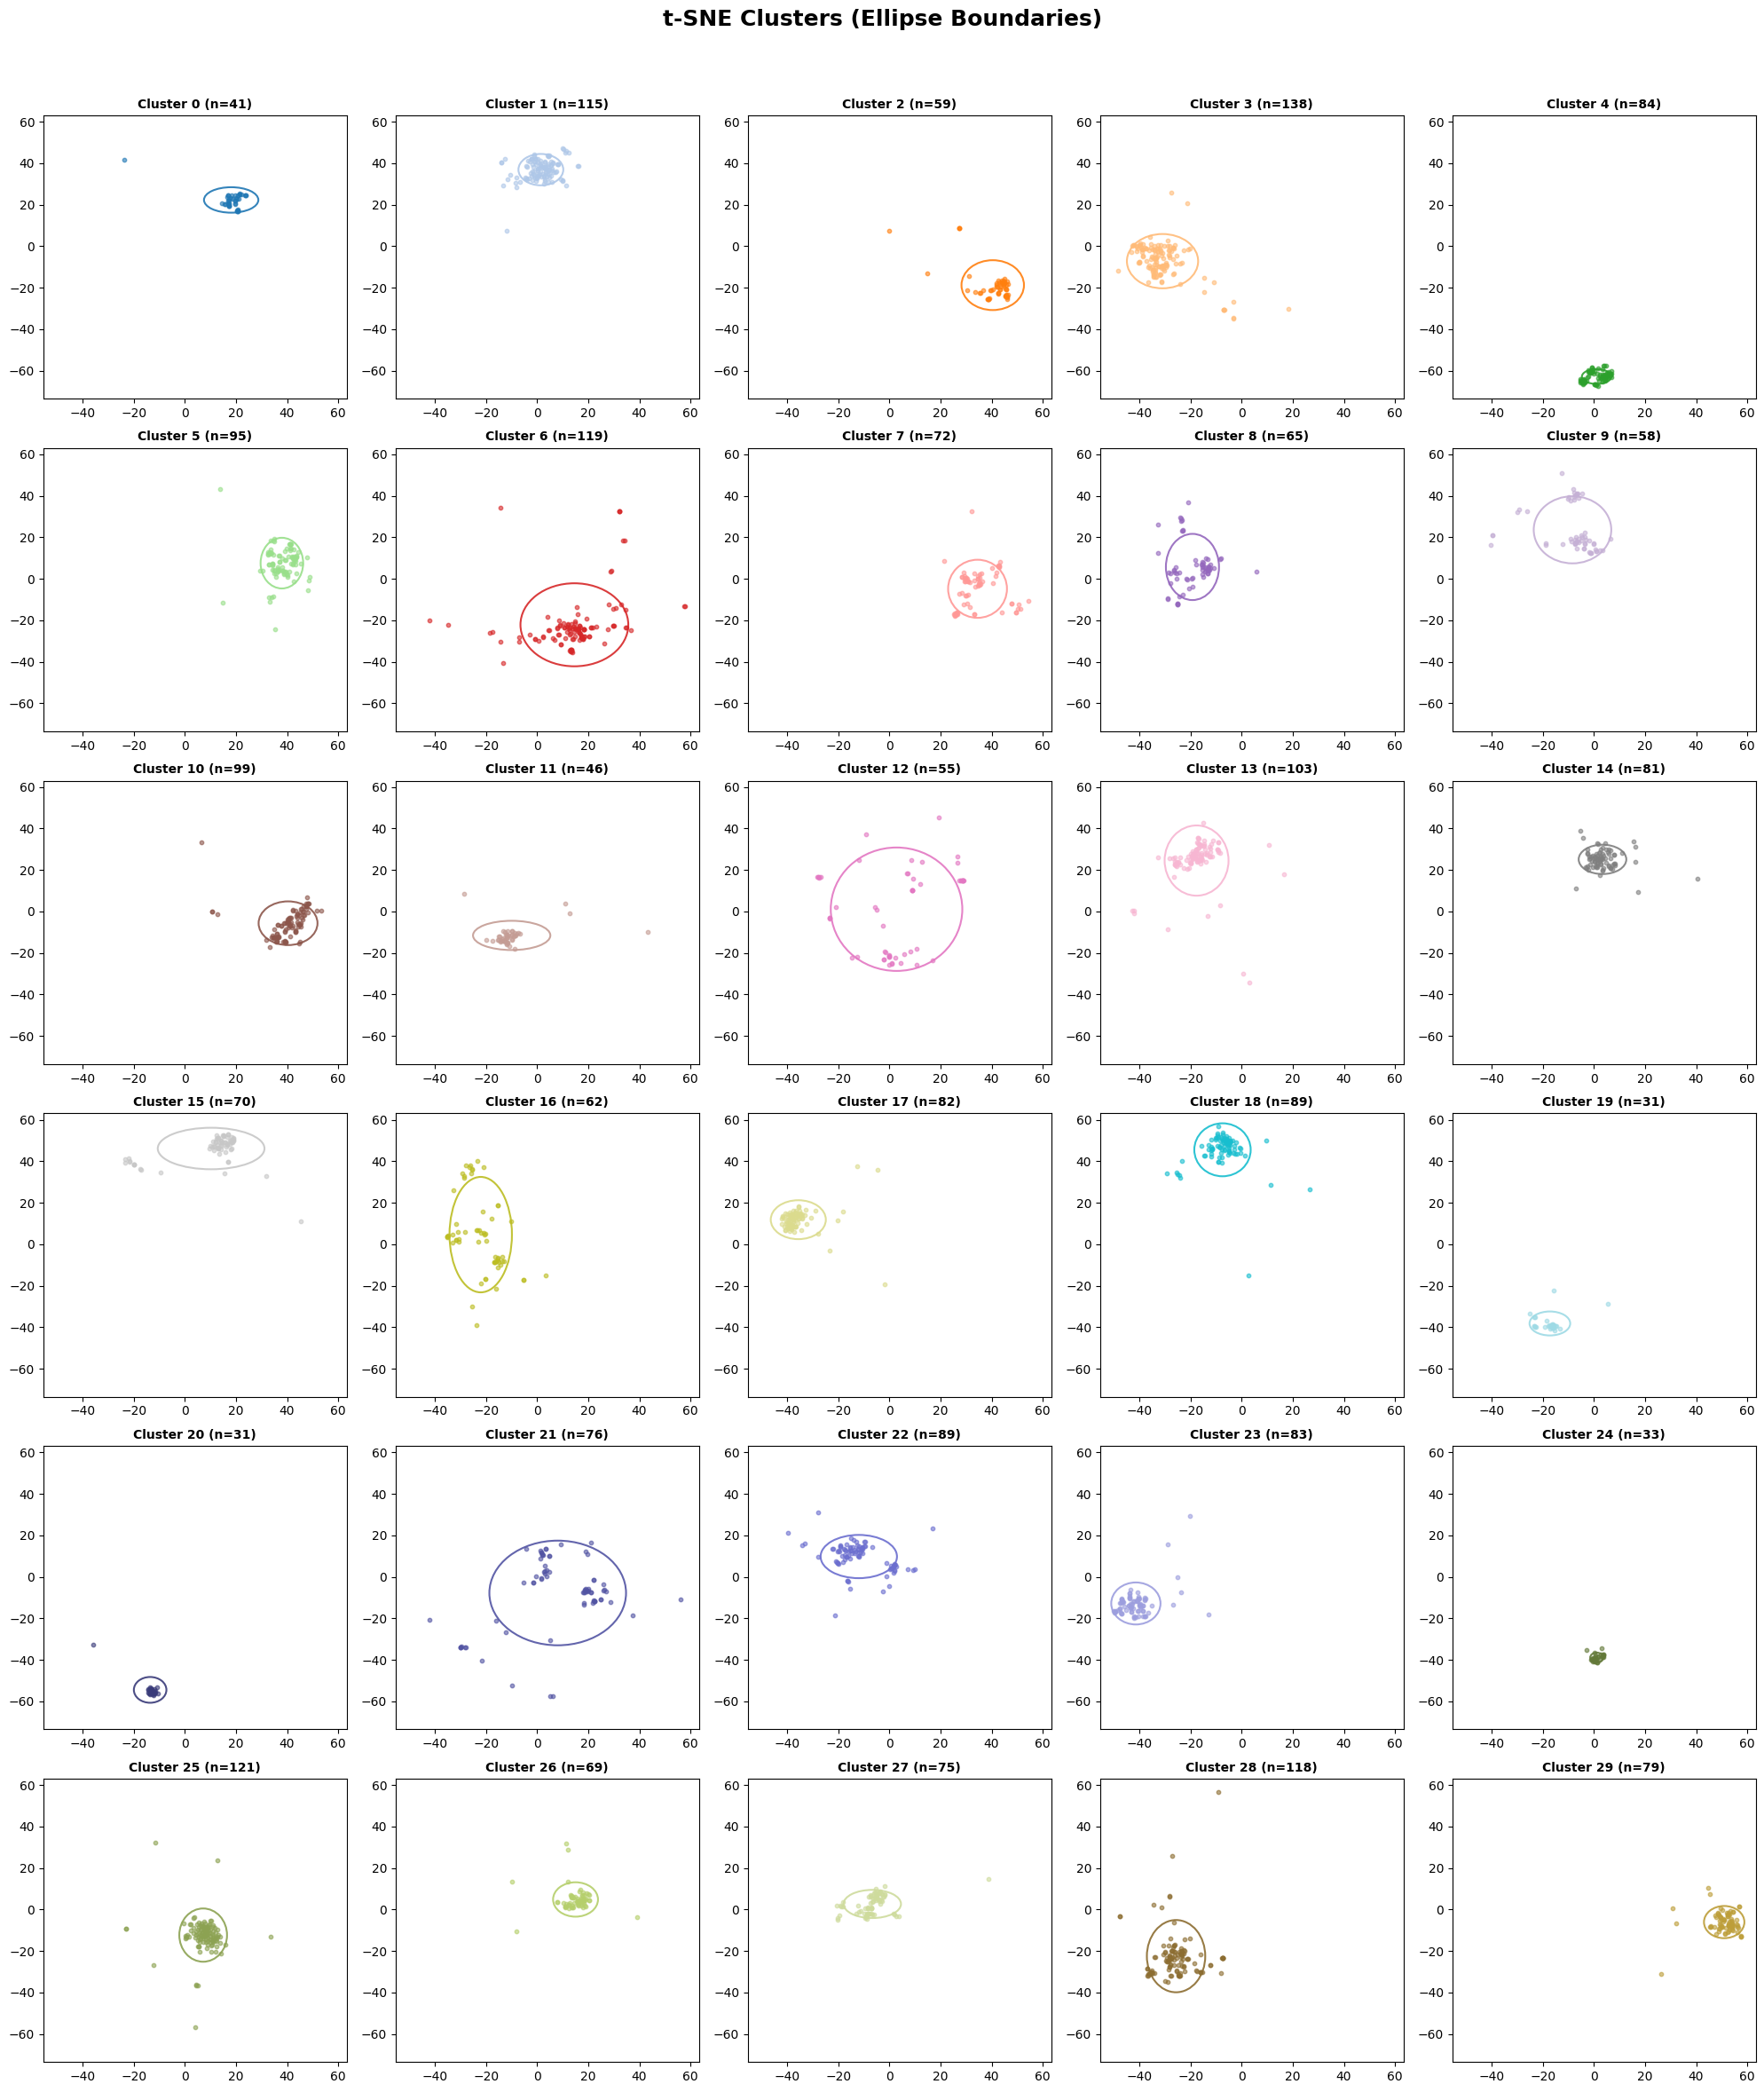

In [18]:
from src.visualization import plot_cluster_grid

# Create cluster grid visualization
fig = plot_cluster_grid(
    viz_df
    # save_path='cluster_grid_tsne.png'  # Uncomment to save
)


In [19]:
from src.consts import OPTIMAL_K

# Define columns to display
columns_show = ['SUBREDDIT', 'POST_COUNT_SOURCE', 'POST_COUNT_TARGET', 'POST_COUNT_TOTAL']

# Display top 5 active subreddits for each cluster
for cluster_id in range(OPTIMAL_K):
    # Get all subreddits in this cluster
    cluster_subreddits = viz_df[viz_df['cluster'] == cluster_id]['subreddit'].tolist()
    
    # Filter total_counts and get top 5 by total post count
    cluster_stats = (
        total_counts[total_counts['SUBREDDIT'].isin(cluster_subreddits)]
        .sort_values(by='POST_COUNT_TOTAL', ascending=False)
        .head(5)[columns_show]
    )
    
    print(f"\n{'='*60}")
    print(f"Cluster {cluster_id} - Top 5 Subreddits (n={len(cluster_subreddits)})")
    print(f"{'='*60}")
    display(cluster_stats)


Cluster 0 - Top 5 Subreddits (n=41)


,SUBREDDIT,POST_COUNT_SOURCE,POST_COUNT_TARGET,POST_COUNT_TOTAL
29846,music,620.0,2278.0,2898.0
20497,hiphopheads,441.0,1280.0,1721.0
13931,electronicmusic,173.0,758.0,931.0
20492,hiphopcirclejerk,768.0,30.0,798.0
13760,edmproduction,240.0,487.0,727.0



Cluster 1 - Top 5 Subreddits (n=115)


,SUBREDDIT,POST_COUNT_SOURCE,POST_COUNT_TARGET,POST_COUNT_TOTAL
45887,titlegore,9503.0,33.0,9536.0
40375,shitpost,6658.0,227.0,6885.0
43579,switcharoo,6039.0,3.0,6042.0
19610,hailcorporate,5360.0,263.0,5623.0
14755,evenwithcontext,2383.0,7.0,2390.0



Cluster 2 - Top 5 Subreddits (n=59)


...

,SUBREDDIT,POST_COUNT_SOURCE,POST_COUNT_TARGET,POST_COUNT_TOTAL
37550,relationships,336.0,2712.0,3048.0
46574,trees,1016.0,1693.0,2709.0
47219,twoxchromosomes,257.0,2188.0,2445.0
13169,drugs,603.0,1322.0,1925.0
11202,darknetmarkets,619.0,1095.0,1714.0



Cluster 28 - Top 5 Subreddits (n=118)


,SUBREDDIT,POST_COUNT_SOURCE,POST_COUNT_TARGET,POST_COUNT_TOTAL
50227,worldnews,303.0,9944.0,10247.0
14677,europe,481.0,2676.0,3157.0
22111,india,1113.0,1818.0,2931.0
7319,canada,491.0,1961.0,2452.0
47672,unitedkingdom,475.0,1438.0,1913.0



Cluster 29 - Top 5 Subreddits (n=79)


,SUBREDDIT,POST_COUNT_SOURCE,POST_COUNT_TARGET,POST_COUNT_TOTAL
17680,gaming,2072.0,6097.0,8169.0
17627,games,1122.0,2200.0,3322.0
17690,gamingcirclejerk,2532.0,73.0,2605.0
11975,destinythegame,558.0,1399.0,1957.0
35924,ps4,548.0,966.0,1514.0


In [20]:
list(viz_df[viz_df['cluster'] == 2]["subreddit"]) # related to esports

['leagueoflegends',
 'globaloffensive',
 'dota2',
 'overwatch',
 'hearthstone',
 'wow',
 '2007scape',
 'smite',
 'runescape',
 'pathofexile',
 'heroesofthestorm',
 'summonerschool',
 'guildwars2',
 'h1z1',
 'starcraft',
 'playrust',
 'osugame',
 'twitch',
 'teamredditteams',
 'blackdesertonline',
 'diablo',
 'mindcrack',
 'archeage',
 'diablo3',
 'wildstar',
 'customhearthstone',
 'wowguilds',
 'learndota2',
 'csgobetting',
 'ice_poseidon',
 'competitiveoverwatch',
 'hearthstonecirclejerk',
 'wowservers',
 'clg',
 'competitivehs',
 'overwatchuniversity',
 'teamsolomid',
 'destiny',
 'livestreamfail',
 'esports',
 'forsen',
 'dota2circlejerk',
 'uhccourtroom',
 'truedota2',
 'allthingsterran',
 'dotamasterrace',
 'starcraftcirclejerk',
 'mindcrackcirclejerk',
 'leagueoflegendsmeta',
 'cloud9',
 'leagueofmeta',
 'circloljerk',
 'dota2modding',
 'dota2betting',
 'supportlol',
 'wowcirclejerk',
 'soargaming',
 'mindcrackdiscussion',
 'thecannibalcaverns']

In [21]:
list(viz_df[viz_df['cluster'] == 19]["subreddit"]) # related to soccer

['fifa',
 'soccer',
 'sports',
 'formula1',
 'reddevils',
 'gunners',
 'cricket',
 'liverpoolfc',
 'mls',
 'boxing',
 'poker',
 'rugbyunion',
 'tennis',
 'chelseafc',
 'coys',
 'soccercirclejerk',
 'soccerstreams',
 'barca',
 'realmadrid',
 'mcfc',
 'aleague',
 'naslsoccer',
 'indycar',
 'wec',
 'footballdownload',
 'ligamx',
 'atletico',
 'uscr',
 'jleague',
 'futebol',
 'soccernerd']

## Search nearest neighbors

Here we manually pick clusters related to a theme (e.g., sports) and visualize them.

In [22]:
# Define multiple themes
THEMES = {
    'sports': ['nfl', 'nba', 'baseball', 'cfb', 'collegebasketball', 'soccer', 'sports', 'mls', 'formula1', 'reddevils'],
    'gaming': ['gaming', 'games', 'pcgaming', 'ps4', 'xboxone', 'nintendo', 'steam'],
    'politics': ['politics', 'the_donald', 'sandersforpresident', 'hillary', 'conservative', 'liberal'],
    'technology': ['technology', 'apple', 'android', 'google', 'microsoft', 'tech', 'gadgets'],
    'entertainment': ['movies', 'television', 'music', 'entertainment', 'netflix', 'marvelstudios']
}

theme = 'sports'  # Change this to explore different themes
picked_subreddits = THEMES[theme]
print(f"Analyzing theme: {theme.upper()}")
print(f"Seed subreddits: {picked_subreddits}")

Analyzing theme: SPORTS
Seed subreddits: ['nfl', 'nba', 'baseball', 'cfb', 'collegebasketball', 'soccer', 'sports', 'mls', 'formula1', 'reddevils']


In [24]:
from src.similarity import similar_by_centroid

centroid_results = similar_by_centroid(
    picked_subreddits, 
    df_subreddits
)

print("📊 Centroid-Based Similarity (average of all seeds):")
centroid_results

📊 Centroid-Based Similarity (average of all seeds):


,SUBREDDIT,SIMILARITY,ORIGINAL
23119,ncaafootball,0.860661,False
18544,ncaa,0.849401,False
10559,theb1g,0.845693,False
14955,bigeast,0.844268,False
23867,miamimls,0.833535,False
14308,acc,0.831292,False
15404,scarletknights,0.830194,False
20484,championsleague,0.827431,False
22199,sec,0.826937,False
2174,worldcup,0.817809,False


In [25]:
from src.similarity import similar_by_max_similarity

max_sim_results = similar_by_max_similarity(
    picked_subreddits, 
    df_subreddits
)

print("\n📊 Max Similarity (closest to any seed):")
max_sim_results


📊 Max Similarity (closest to any seed):


,SUBREDDIT,MAX_SIMILARITY,CLOSEST_SEED,IS_SEED
6604,uslpro,0.960580,reddevils,False
14502,npsl,0.958882,reddevils,False
2803,ussoccer,0.949216,reddevils,False
7621,sportingkc,0.947176,reddevils,False
6570,nwsl,0.946875,reddevils,False
9370,realsaltlake,0.946160,reddevils,False
10644,dcunited,0.944229,reddevils,False
923,greenbaypackers,0.942680,baseball,False
4854,minnesotaunited,0.939800,reddevils,False
3757,acmilan,0.938837,mls,False
